In [2]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import json
import boost_histogram as bh
import uproot
from scipy.stats import beta
import hist
import hist.intervals
import awkward as ak

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

In [3]:
with open('../configs/sample_configs/signal_2022_Mchi_10_30_50_aEM.json') as file:
    sig_file = json.load(file)

In [4]:
loc = sig_file[0]["location"]
sig_root = uproot.open(loc)
sig_root.keys()
ntuple = sig_root["ntuples/outT"]
ntuple.keys()

['trigFired',
 'eventNum',
 'lumiSec',
 'runNum',
 'trig_HLT_PFMET110_PFMHT110_IDTight',
 'trig_HLT_PFMET120_PFMHT120_IDTight',
 'trig_HLT_PFMET130_PFMHT130_IDTight',
 'trig_HLT_PFMET140_PFMHT140_IDTight',
 'trig_HLT_PFMETNoMu120_PFMHTNoMu120_IDTight',
 'trig_HLT_PFMETTypeOne110_PFMHT110_IDTight',
 'trig_HLT_PFMETTypeOne120_PFMHT120_IDTight',
 'trig_HLT_PFMETTypeOne130_PFMHT130_IDTight',
 'trig_HLT_PFMETTypeOne140_PFMHT140_IDTight',
 'trig_HLT_PFJet15',
 'trig_HLT_PFJet25',
 'trig_HLT_PFJet40',
 'trig_HLT_PFJet60',
 'trig_HLT_PFJet80',
 'trig_HLT_PFJet140',
 'trig_HLT_PFJet200',
 'trig_HLT_PFJet260',
 'trig_HLT_PFJet320',
 'trig_HLT_PFJet400',
 'trig_HLT_PFJet450',
 'trig_HLT_PFJet500',
 'trig_HLT_PFJet550',
 'trig_HLT_AK4PFJet30',
 'trig_HLT_AK4PFJet50',
 'trig_HLT_AK4PFJet80',
 'trig_HLT_AK4PFJet100',
 'trig_HLT_AK4PFJet120',
 'trig_HLT_Ele35_WPTight_Gsf_L1EGMT',
 'trig_HLT_Ele32_WPTight_Gsf',
 'trig_HLT_Ele23_CaloIdL_TrackIdL_IsoVL_PFJet30',
 'trig_HLT_Ele23_Ele12_CaloIdL_TrackIdL_I

In [19]:
gen_vxy_ele=ntuple["GenEle_vxy"].array()
print("GenEle_vxy:",gen_vxy_ele)
# flat_Electron = ak.flatten(Electron_vxy)
# print ("flat:", flat_Electron)

gen_vxy_pos=ntuple["GenPos_vxy"].array()
print("GenPos_vxy:",gen_vxy_pos)


Electron_vxy=ntuple["Electron_vxy"].array()
print("Electrons vxy:",Electron_vxy)
flat_Electron = ak.flatten(Electron_vxy)
print ("flat:", flat_Electron)




LptElectron_vxy=ntuple["LptElectron_vxy"].array()
print("low pT electrons vxy:",LptElectron_vxy)
flat_lpt = ak.flatten(LptElectron_vxy)
print ("flat:", flat_lpt)


GenEle_vxy: [0.101, 0.102, 0.101, 0.102, 0.101, 0.101, ... 0.102, 0.0999, 0.1, 0.1, 0.101, 0.102]
GenPos_vxy: [0.101, 0.102, 0.101, 0.102, 0.101, 0.101, ... 0.102, 0.0999, 0.1, 0.1, 0.101, 0.102]
Electrons vxy: [[], [], [], [], [], [], [], [], [], ... [0.0948], [], [], [], [], [], [], [], []]
flat: [0.102, 0.102, 0.101, 0.102, 0.102, 0.103, ... 0.0955, 0.103, 0.105, 0.101, 0.0948]
low pT electrons vxy: [[0.259, 0.108], [], [0.0959], [0.103], ... [], [0.0992, 0.0317], [0.101], [0.102]]
flat: [0.259, 0.108, 0.0959, 0.103, 0.102, ... 0.0995, 0.0992, 0.0317, 0.101, 0.102]


counts: [0 0 0 ... 0 0 0]
bins: [0.00000000e+00 1.00010001e-04 2.00020002e-04 ... 9.99799980e-01
 9.99899990e-01 1.00000000e+00]


[StairsArtists(stairs=<matplotlib.patches.StepPatch object at 0x7f77f7435cd0>, errorbar=None, legend_artist=None)]

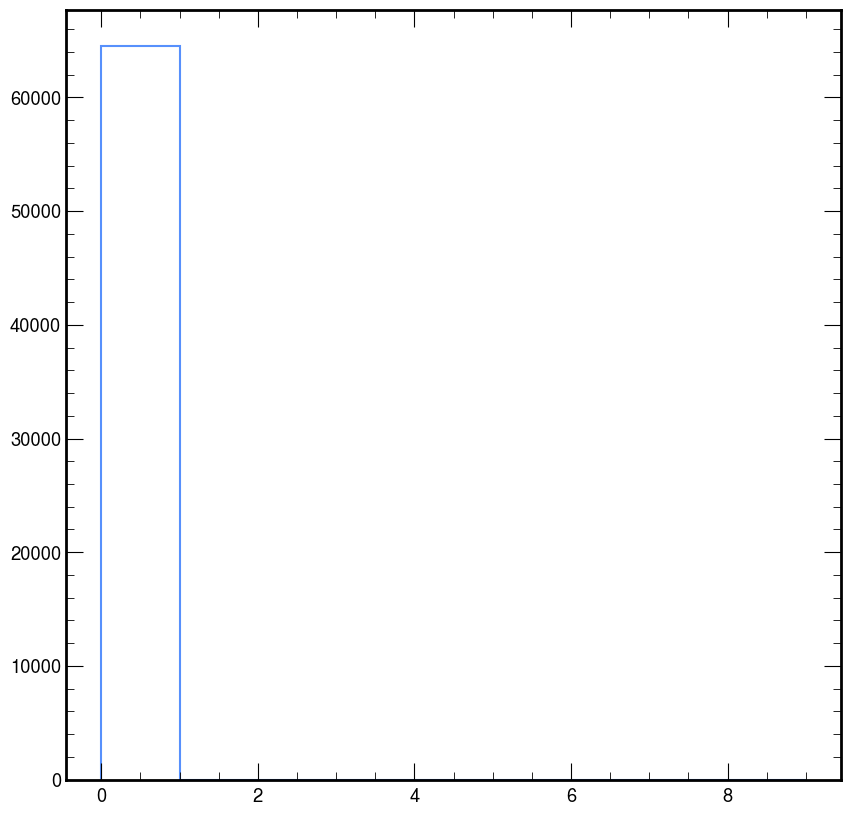

In [33]:
fig, ax = plt.subplots()
bins = np.linspace(0,1,100000)  

#Denominator 
counts_gen_ele_vxy, bins_den  = np.histogram(gen_vxy_ele, bins)

# counts_flat_lpt, bins_den  = np.histogram(flat_lpt, bins)

# counts = counts_gen_P_pt+ counts_gen_E_pt
# print (counts)
print ("counts:",counts_gen_ele_vxy)
print ("bins:",bins_den)

mplhep.histplot(counts_flat_Electron)


In [ ]:
fig, ax = plt.subplots()
bins = np.linspace(0, 50, 50)  

#Denominator 
counts_gen_P_pt, bins_den  = np.histogram(gen_P_pt, bins)
counts_gen_E_pt, bins_den  = np.histogram(gen_E_pt, bins)

counts = counts_gen_P_pt+ counts_gen_E_pt
print (counts)

mplhep.histplot(counts)
ax.set_xlabel("Gen-Electrons pT (in GeV)")